## Refraction

### Snell's Law
Snell's law relates the angle of incidence $\alpha$ and the angle of refraction $\beta$ through

$$n_1 \sin(\alpha) = n_2 \sin(\beta).$$

For light entering the block from air we use $n_1 \approx 1$, so

$$\sin(\alpha) = n \sin(\beta),$$

where $n$ is the refractive index of the block relative to air. Two different graphical analyses are used below to determine $n$.

#### Graphing $\sin\alpha$ vs. $\sin\beta$

This is the most direct linear test of Snell's law. If we plot $y = \sin(\alpha)$ against $x = \sin(\beta)$, the model becomes

$$y = n x,$$

so the slope of the best-fit line is the refractive index. The uncertainty of the sine values is obtained by Gaussian error propagation,

$$d(\sin\theta) = |\cos\theta| \, d\theta,$$

with the angular uncertainty expressed in radians.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Enter the measured angles in degrees.
alpha = np.array([60, 39, 21, 7, 13.5, 32.5, 47.5, 27])  # angle of incidence
beta = np.array([37, 26, 14, 5, 11.5, 21, 31, 19])   # angle of refraction

dalpha = 1.0  # uncertainty of alpha in degrees
dbeta = 2.0   # uncertainty of beta in degrees

def require_data(*arrays):
    if any(np.size(arr) == 0 for arr in arrays):
        raise ValueError('Enter your measured data in the arrays before running the analysis cells.')

def line_through_origin(x, m):
    return m * x

def beta_model(alpha_deg, n):
    alpha_rad = np.deg2rad(alpha_deg)
    argument = np.sin(alpha_rad) / n
    argument = np.clip(argument, -1, 1)
    return np.rad2deg(np.arcsin(argument))

def displacement_model(alpha_deg, n, thickness_cm):
    alpha_rad = np.deg2rad(alpha_deg)
    beta_rad = np.arcsin(np.clip(np.sin(alpha_rad) / n, -1, 1))
    return thickness_cm * np.sin(alpha_rad - beta_rad) / np.cos(beta_rad)

require_data(alpha, beta)

if alpha.shape != beta.shape:
    raise ValueError('alpha and beta must have the same length.')

alpha_rad = np.deg2rad(alpha)
beta_rad = np.deg2rad(beta)
dalpha_rad = np.deg2rad(dalpha)
dbeta_rad = np.deg2rad(dbeta)

sin_alpha = np.sin(alpha_rad)
sin_beta = np.sin(beta_rad)
dsin_alpha = np.abs(np.cos(alpha_rad)) * dalpha_rad
dsin_beta = np.abs(np.cos(beta_rad)) * dbeta_rad


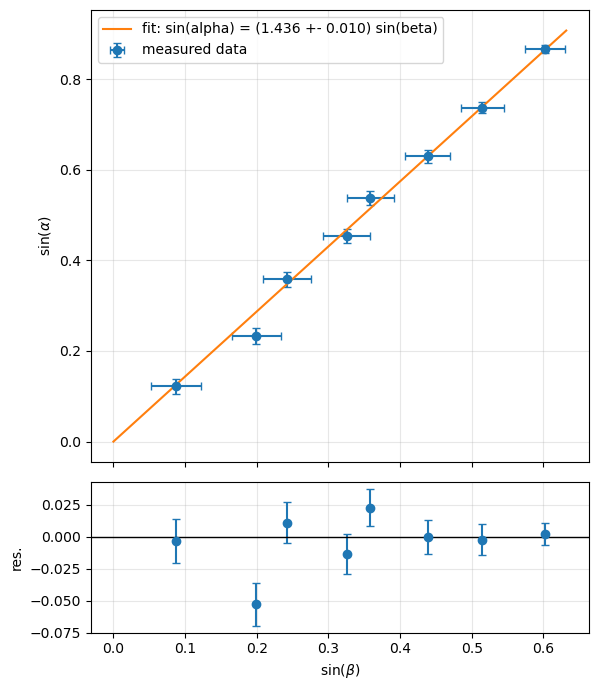

In [15]:
popt_sin, pcov_sin = curve_fit(
    line_through_origin,
    sin_beta,
    sin_alpha,
    sigma=dsin_alpha,
    absolute_sigma=True,
)
n_sin = popt_sin[0]
dn_sin = np.sqrt(np.diag(pcov_sin))[0]

sin_beta_fit = np.linspace(0, 1.05 * np.max(sin_beta), 300)
sin_alpha_fit = line_through_origin(sin_beta_fit, n_sin)
residuals_sin = sin_alpha - line_through_origin(sin_beta, n_sin)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(sin_beta, sin_alpha, xerr=dsin_beta, yerr=dsin_alpha, fmt='o', capsize=3, label='measured data')
ax.plot(sin_beta_fit, sin_alpha_fit, label=f'fit: sin(alpha) = ({n_sin:.3f} +- {dn_sin:.3f}) sin(beta)')
ax.set_ylabel(r'$\sin(\alpha)$')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(sin_beta, residuals_sin, yerr=dsin_alpha, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\sin(\beta)$')
ax_res.set_ylabel('res.')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Refractive Index
From Snell's law in the form $\sin(\alpha) = n \sin(\beta)$, the slope of the graph $\sin(\alpha)$ vs. $\sin(\beta)$ is directly equal to the refractive index $n$ of the material relative to air. A slope larger than 1 is expected because the refracted angle is smaller than the incident angle when light enters the optically denser medium.

In [16]:
print(f'Refractive index from the sine graph: n = {n_sin:.3f} +- {dn_sin:.3f}')

Refractive index from the sine graph: n = 1.436 +- 0.010


#### Graphing $\beta$ vs. $\alpha$

The dependence of $\beta$ on $\alpha$ is not linear. As the angle of incidence increases, the angle of refraction also increases, but more slowly, so the deviation between both angles becomes larger. For this reason the data are fitted with the model obtained directly from Snell's law:

$$\beta(\alpha) = \arcsin\left(\frac{\sin(\alpha)}{n}\right).$$

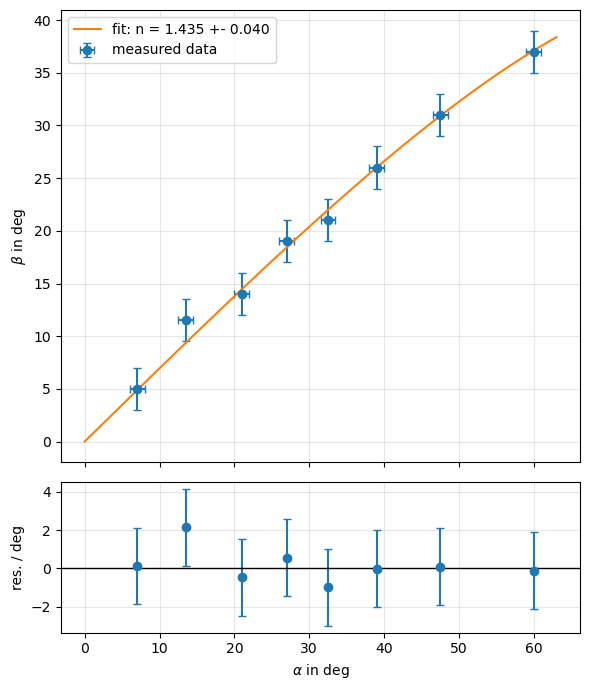

In [17]:
sigma_beta = np.full_like(beta, dbeta, dtype=float)
popt_beta, pcov_beta = curve_fit(
    beta_model,
    alpha,
    beta,
    p0=[n_sin],
    sigma=sigma_beta,
    absolute_sigma=True,
    bounds=(1.0, 3.0),
)
n_beta = popt_beta[0]
dn_beta = np.sqrt(np.diag(pcov_beta))[0]

alpha_fit = np.linspace(0, 1.05 * np.max(alpha), 300)
beta_fit = beta_model(alpha_fit, n_beta)
residuals_beta = beta - beta_model(alpha, n_beta)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(alpha, beta, xerr=dalpha, yerr=dbeta, fmt='o', capsize=3, label='measured data')
ax.plot(alpha_fit, beta_fit, label=f'fit: n = {n_beta:.3f} +- {dn_beta:.3f}')
ax.set_ylabel(r'$\beta$ in deg')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(alpha, residuals_beta, yerr=dbeta, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\alpha$ in deg')
ax_res.set_ylabel('res. / deg')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Refractive Index
In the non-linear fit of $\beta$ as a function of $\alpha$, the refractive index appears directly as the fit parameter in the expression $\beta = \arcsin(\sin(\alpha)/n)$. The fitted value of $n$ can therefore be read off immediately from the model parameter.

In [13]:
print(f'Refractive index from the angle graph: n = {n_beta:.3f} +- {dn_beta:.3f}')

Refractive index from the angle graph: n = 1.433 +- 0.040


#### Discussion
Both graphical methods should give compatible values of the refractive index within their uncertainties. The linear plot of $\sin(\alpha)$ against $\sin(\beta)$ is usually preferable because Snell's law predicts a straight line through the origin, making deviations from the model easy to identify in the residual plot. The $\beta$ vs. $\alpha$ graph is still useful because it shows the physical trend directly: the greater the angle of incidence, the greater the angle of refraction, but the refracted ray remains closer to the normal, so the difference $\alpha - \beta$ increases with angle. Small systematic offsets can arise from reading the protractor, defining the normal inaccurately, or misaligning the ray with the center of the block.

#### Parallel displacement
For a plane-parallel plate of thickness $d$, the emergent ray is parallel to the incident ray but shifted sideways by a distance $s$. From the geometry of the ray path one obtains

$$s = \frac{d \sin(\alpha - \beta)}{\cos(\beta)}.$$

Using Snell's law, the refraction angle is

$$\beta = \arcsin\left(\frac{\sin(\alpha)}{n}\right),$$

so the expected displacement as a function of the angle of incidence is

$$s(\alpha) = \frac{d \sin\!\left(\alpha - \arcsin(\sin(\alpha)/n)\right)}{\cos\!\left(\arcsin(\sin(\alpha)/n)\right)}.$$

This expression can be compared with the measured lateral displacement.

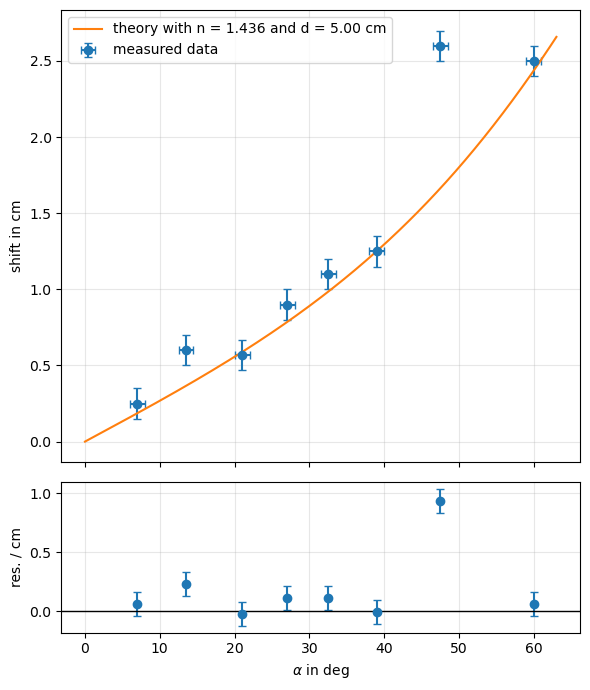

Using n = 1.436 +- 0.010 and d = 5.00 +- 0.50 cm.


In [19]:
# Enter the measurements for the parallel displacement here.
alpha_shift = alpha  # angle of incidence in degrees
shift = np.array([2.5, 1.25, 0.567, 0.25, 0.6, 1.1, 2.6, 0.9])         # parallel displacement in cm
dshift = 0.1                # uncertainty of the displacement in cm

# Thickness of the plate in cm.
thickness = 5
dthickness = 0.5

require_data(alpha_shift, shift)

if alpha_shift.shape != shift.shape:
    raise ValueError('alpha_shift and shift must have the same length.')
if thickness <= 0:
    raise ValueError('Enter the plate thickness in the variable thickness.')

shift_fit = np.linspace(0, 1.05 * np.max(alpha_shift), 300)
shift_theory = displacement_model(shift_fit, n_sin, thickness)
shift_residuals = shift - displacement_model(alpha_shift, n_sin, thickness)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(alpha_shift, shift, xerr=dalpha, yerr=dshift, fmt='o', capsize=3, label='measured data')
ax.plot(shift_fit, shift_theory, label=f'theory with n = {n_sin:.3f} and d = {thickness:.2f} cm')
ax.set_ylabel('shift in cm')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(alpha_shift, shift_residuals, yerr=dshift, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\alpha$ in deg')
ax_res.set_ylabel('res. / cm')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Using n = {n_sin:.3f} +- {dn_sin:.3f} and d = {thickness:.2f} +- {dthickness:.2f} cm.')

#### Discussion
The parallel displacement should increase with the angle of incidence because the light travels a longer oblique path inside the plate before emerging again. For small angles the displacement is small, while for larger angles it becomes clearly visible. Agreement between the measured points and the theoretical curve supports both the geometrical derivation and the refractive index obtained from Snell's law. Remaining deviations can be explained by uncertainty in the thickness of the plate, limited precision when tracing the rays, and the fact that the displacement is harder to read accurately than the angles themselves.